### [Isotonic Regression in Sklearn](https://medium.com/chat-gpt-now-writes-all-my-articles/back-to-basics-isotonic-regression-in-sklearn-3272cb1b7e21)

Isotonic Regression is a non-parametric method that fits a non-decreasing (or non-increasing) function to 1-dimensional data. Unlike linear regression, it doesn't assume a straight-line relationship — instead, it enforces monotonicity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

import warnings
warnings.filterwarnings('ignore')

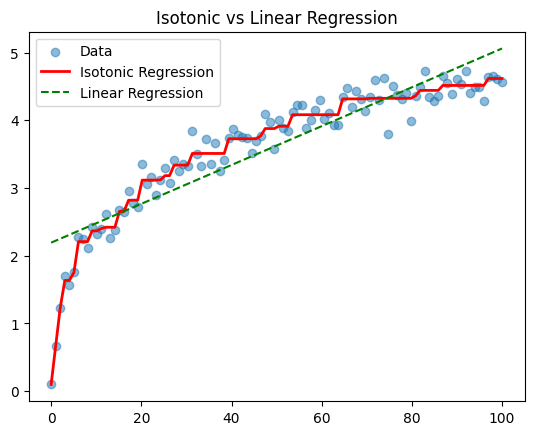

In [2]:
# Simulated data
x = np.linspace(0, 100, 100)
y = np.log(x + 1) + np.random.normal(0, 0.2, size=100)  # noisy log relationship

# Isotonic Regression
iso_reg = IsotonicRegression(increasing=True)
y_iso = iso_reg.fit_transform(x, y)

# Linear Regression for comparison
lin_reg = LinearRegression().fit(x.reshape(-1, 1), y)
y_lin = lin_reg.predict(x.reshape(-1, 1))

# Plot
plt.scatter(x, y, label="Data", alpha=0.5)
plt.plot(x, y_iso, color="red", label="Isotonic Regression", linewidth=2)
plt.plot(x, y_lin, color="green", linestyle="--", label="Linear Regression")
plt.legend()
plt.title("Isotonic vs Linear Regression")
plt.show()

#### Real-World Use Case

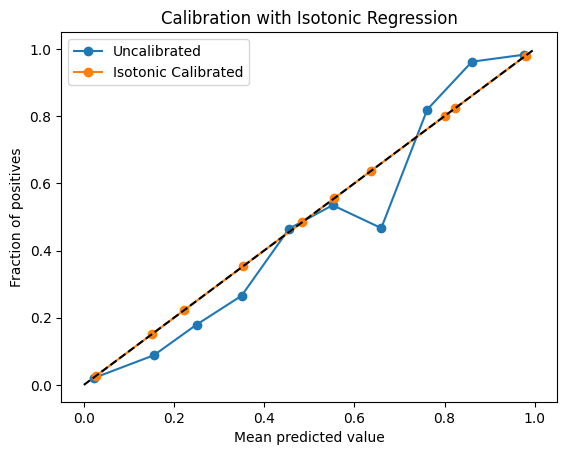

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

# Generate data
X, y = make_classification(n_samples=5000, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train classifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
probs = clf.predict_proba(X_test)[:, 1]

# Calibrate with Isotonic Regression
iso_cal = IsotonicRegression(out_of_bounds="clip")
probs_cal = iso_cal.fit_transform(probs, y_test)

# Calibration curves
fop, mpv = calibration_curve(y_test, probs, n_bins=10)
fop_cal, mpv_cal = calibration_curve(y_test, probs_cal, n_bins=10)
plt.plot(mpv, fop, label="Uncalibrated", marker="o")
plt.plot(mpv_cal, fop_cal, label="Isotonic Calibrated", marker="o")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.title("Calibration with Isotonic Regression")
plt.legend()
plt.show()

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

clf.fit(X_tr, y_tr)
val_probs = clf.predict_proba(X_val)[:, 1]
test_probs = clf.predict_proba(X_test)[:, 1]

iso_cal = IsotonicRegression(out_of_bounds="clip")
iso_cal.fit(val_probs, y_val)

test_probs_cal = iso_cal.transform(test_probs)

In [4]:
from sklearn.metrics import brier_score_loss
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.metrics import precision_recall_curve

brier_uncal = brier_score_loss(y_test, probs)
brier_cal = brier_score_loss(y_test, probs_cal)
print("Brier score (uncalibrated):", brier_uncal)
print("Brier score (isotonic):", brier_cal)

auc_uncal = roc_auc_score(y_test, probs)
auc_cal = roc_auc_score(y_test, probs_cal)
print("AUC (uncal):", auc_uncal)
print("AUC (cal):", auc_cal)

logloss_uncal = log_loss(y_test, probs)
logloss_cal = log_loss(y_test, probs_cal)
print("Log loss (uncal):", logloss_uncal)
print("Log loss (cal):", logloss_cal)

precision, recall, thresholds = precision_recall_curve(y_test, probs_cal)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1.argmax()
best_threshold = thresholds[best_idx]
print("Best calibrated threshold:", best_threshold)

Brier score (uncalibrated): 0.061629399999999994
Brier score (isotonic): 0.057660075100856564
AUC (uncal): 0.9684150730038616
AUC (cal): 0.9713371832528501
Log loss (uncal): 0.36573576439579875
Log loss (cal): 0.2022690326021503
Best calibrated threshold: 0.47058823529411764


In [5]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0

    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            acc = y_true[mask].mean()
            conf = y_prob[mask].mean()
            ece += np.abs(acc - conf) * mask.mean()
    return ece

ece_uncal = expected_calibration_error(y_test, probs)
ece_cal = expected_calibration_error(y_test, probs_cal)
print("ECE (uncal):", ece_uncal)
print("ECE (cal):", ece_cal)

ECE (uncal): 0.03331333333333331
ECE (cal): 2.077042241902897e-17


In [6]:
from sklearn.calibration import CalibratedClassifierCV

platt_clf = CalibratedClassifierCV(
    estimator=clf,
    method="sigmoid",
    cv=5
)
platt_clf.fit(X_train, y_train)

platt_probs = platt_clf.predict_proba(X_test)[:, 1]

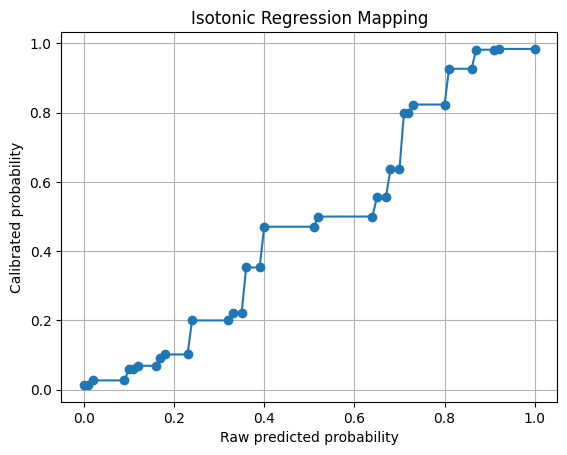

In [7]:
plt.plot(iso_cal.X_thresholds_, iso_cal.y_thresholds_, marker="o")
plt.xlabel("Raw predicted probability")
plt.ylabel("Calibrated probability")
plt.title("Isotonic Regression Mapping")
plt.grid(True)
plt.show()

In [8]:
import joblib

joblib.dump(clf, "rf_model.pkl")
joblib.dump(iso_cal, "isotonic_calibrator.pkl")

['isotonic_calibrator.pkl']